# **Author: Mukhamedali Daniyaruly**
# **Topic: Research a Diffusion Transformers for generating image**

In [ ]:
import os
import re
import math
from dataclasses import dataclass
from tqdm.auto import tqdm
from datasets import load_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn.functional as F
from torch.optim import Adam

import torchvision
from torchvision.transforms import transforms
from einops import rearrange

# **Configuration**

In [ ]:
@dataclass
class Configuration:
  # diffusion params
  num_timesteps: int = 1000
  beta_start: float = 0.0001
  beta_end: float = 0.02

  # dit params
  patch_size: int = 2
  num_layers: int = 6
  hidden_dim: int = 384
  num_heads: int = 6
  head_dim: int = 64
  timestep_emb_dim: int = 384

  # autoencoder params
  z_channels: int = 4
  codebook_size: int = 8192
  down_channels = [128, 256, 384]
  mid_channels = [384]
  att_down = [False, False]
  norm_channels: int = 32
  num_heads: int = 4
  num_down_layers: int = 2
  num_mid_layers: int = 2
  num_up_layers: int = 2

  # train params
  seed: int = 1111

config = Configuration()

# **Dataset**

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
ds = load_dataset("huggan/pokemon")

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
dataset = torchvision.datasets.CIFAR10(root="./", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=80, shuffle=True)

In [ ]:
for images, labels in dataloader:
  print(images.shape)
  break

torch.Size([80, 3, 32, 32])


# **Architecture**

In [ ]:
def get_patch_position_embedding(pos_emb_dim, grid_size, device):
  grid_size_h, grid_size_w = grid_size
  grid_h = torch.arange(grid_size_h, dtype=torch.float32, device=device)
  grid_w = torch.arange(grid_size_w, dtype=torch.float32, device=device)
  grid = torch.meshgrid(grid_h, grid_w, indexing='ij')
  grid = torch.stack(grid, dim=0)

  grid_h_positions = grid[0].reshape(-1)
  grid_w_positions = grid[1].reshape(-1)

  factor = 10000 ** (torch.arange(0, pos_emb_dim // 4, dtype=torch.float32, device=device) / (pos_emb_dim // 4))

  grid_h_emb = grid_h_positions[:, None] / factor
  grid_h_emb = torch.cat([torch.sin(grid_h_emb), torch.cos(grid_h_emb)], dim=-1)

  grid_w_emb = grid_w_positions[:, None] / factor
  grid_w_emb = torch.cat([torch.sin(grid_w_emb), torch.cos(grid_w_emb)], dim=-1)

  pos_emb = torch.cat([grid_h_emb, grid_w_emb], dim=-1)
  return pos_emb

In [ ]:
class PatchEmbedding(nn.Module):
  def __init__(self, in_channels, hidden_size, patch_size):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, hidden_size, kernel_size=patch_size, stride=patch_size)

  def forward(self, x):
    out = self.conv(x)
    out = out.flatten(2)
    out = out.transpose(1, 2)
    return out

In [ ]:
class PatchEmbedding(nn.Module):
  def __init__(self, image_height, image_width, in_channels, patch_height, patch_width, hidden_size):
    super().__init__()
    self.image_height = image_height
    self.image_width = image_width
    self.in_channels = in_channels
    self.hidden_size = hidden_size
    self.patch_height = patch_height
    self.patch_width = patch_width

    patch_dim = self.in_channels * self.patch_height * self.patch_width
    self.patch_embed = nn.Linear(patch_dim, self.hidden_size)

    nn.init.xavier_uniform_(self.patch_embed.weight)
    nn.init.constant_(self.patch_embed.bias, val=0)

  def forward(self, x):
    grid_size_h = self.image_height // self.patch_height
    grid_size_w = self.image_width // self.patch_width

    out = rearrange(x, "b c (nh ph) (nw pw) -> b (nh nw) (ph pw c)", ph=self.patch_height, pw=self.patch_width)
    out = self.patch_embed(out)

    pos_embed = get_patch_position_embedding(pos_emb_dim=self.hidden_size, grid_size=(grid_size_h, grid_size_w), device=x.device)
    out += pos_embed.unsqueeze(0)
    return out

In [ ]:
class Attention(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.n_heads = config.num_heads
    self.hidden_size = config.hidden_dim
    self.head_dim = config.head_dim
    self.attn_dim = self.n_heads * self.head_dim

    self.qkv_proj = nn.Linear(self.hidden_size, 3 * self.attn_dim, bias=True)
    self.output_proj = nn.Linear(self.attn_dim, self.hidden_size)

    nn.init.xavier_uniform_(self.qkv_proj.weight)
    nn.init.constant_(self.qkv_proj.bias, 0)
    nn.init.xavier_uniform_(self.output_proj.weight)
    nn.init.constant_(self.output_proj.bias, 0)

  def forward(self, x):
    B, N, C = x.shape
    qkv = self.qkv_proj(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]

    # Используем встроенный Flash Attention (очень быстро и экономит VRAM)
    out = F.scaled_dot_product_attention(q, k, v)

    out = out.transpose(1, 2).reshape(B, N, self.attn_dim)
    return self.output_proj(out)

In [ ]:
class TransformerLayer(nn.Module):
  def __init__(self, config):
    super().__init__()

    self.hidden_size = config.hidden_dim
    ff_hidden_dim = 4 * self.hidden_size

    self.att_norm = nn.LayerNorm(self.hidden_size, elementwise_affine=False, eps=1e-6)
    self.attn_block = Attention(config)
    self.ff_norm = nn.LayerNorm(self.hidden_size, elementwise_affine=False, eps=1e-6)

    self.mlp_block = nn.Sequential(
        nn.Linear(self.hidden_size, ff_hidden_dim),
        nn.GELU(approximate="tanh"),
        nn.Linear(ff_hidden_dim, self.hidden_size),
    )

    self.adaptive_norm_mlp = nn.Sequential(
        nn.SiLU(),
        nn.Linear(self.hidden_size, 6 * self.hidden_size, bias=True)
    )

    nn.init.xavier_uniform_(self.mlp_block[0].weight)
    nn.init.constant_(self.mlp_block[0].bias, 0)
    nn.init.xavier_uniform_(self.mlp_block[-1].weight)
    nn.init.constant_(self.mlp_block[-1].bias, 0)

    nn.init.constant_(self.adaptive_norm_mlp[-1].weight, 0)
    nn.init.constant_(self.adaptive_norm_mlp[-1].bias, 0)

  def forward(self, x, condition):
    scale_shift_params = self.adaptive_norm_mlp(condition).chunk(6, dim=1)
    (pre_attn_shift, pre_attn_scale, post_attn_scale, pre_mlp_shift, pre_mlp_scale, post_mlp_scale) = scale_shift_params

    # Attention block
    attn_norm_output = (self.att_norm(x) * (1 + pre_attn_scale.unsqueeze(1)) + pre_attn_shift.unsqueeze(1))
    x = x + post_attn_scale.unsqueeze(1) * self.attn_block(attn_norm_output)

    # MLP block
    mlp_norm_output = (self.ff_norm(x) * (1 + pre_mlp_scale.unsqueeze(1)) + pre_mlp_shift.unsqueeze(1))
    x = x + post_mlp_scale.unsqueeze(1) * self.mlp_block(mlp_norm_output)

    return x

In [ ]:
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    exponent = -math.log(10000) * torch.arange(half_dim, dtype=torch.float32, device=timesteps.device)
    exponent = exponent / half_dim
    emb = torch.exp(exponent)
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
    return emb

class DIT(nn.Module):
  def __init__(self, image_size, in_channels, config):
    super().__init__()

    self.num_layers = config.num_layers
    self.image_height, self.image_width = image_size if isinstance(image_size, tuple) else (image_size, image_size)
    self.in_channels = in_channels
    self.hidden_size = config.hidden_dim
    self.patch_height = config.patch_size
    self.patch_width = config.patch_size
    self.timestep_emb_dim = config.timestep_emb_dim

    self.nh = self.image_height // self.patch_height
    self.nw = self.image_width // self.patch_width

    self.patch_embed_layer = PatchEmbedding(
        image_height=self.image_height,
        image_width=self.image_width,
        in_channels=self.in_channels,
        patch_height=self.patch_height,
        patch_width=self.patch_width,
        hidden_size=self.hidden_size
    )

    self.t_proj = nn.Sequential(
        nn.Linear(self.timestep_emb_dim, self.hidden_size),
        nn.SiLU(),
        nn.Linear(self.hidden_size, self.hidden_size)
    )

    self.layers = nn.ModuleList([TransformerLayer(config) for _ in range(self.num_layers)])
    self.norm = nn.LayerNorm(self.hidden_size, elementwise_affine=False, eps=1e-6)
    self.adaptive_norm_mlp = nn.Sequential(
        nn.SiLU(),
        nn.Linear(self.hidden_size, 2 * self.hidden_size, bias=True)
    )
    self.proj_out = nn.Linear(self.hidden_size, self.patch_height * self.patch_width * self.in_channels)

    nn.init.normal_(self.t_proj[0].weight, std=0.02)
    nn.init.normal_(self.t_proj[2].weight, std=0.02)
    nn.init.constant_(self.adaptive_norm_mlp[-1].weight, 0)
    nn.init.constant_(self.adaptive_norm_mlp[-1].bias, 0)
    nn.init.constant_(self.proj_out.weight, 0)
    nn.init.constant_(self.proj_out.bias, 0)

  def forward(self, x, t):
    out = self.patch_embed_layer(x)
    t_emb = get_timestep_embedding(t, self.timestep_emb_dim)
    t_emb = self.t_proj(t_emb)

    for layer in self.layers:
      out = layer(out, t_emb)

    shift, scale = self.adaptive_norm_mlp(t_emb).chunk(2, dim=1)
    out = (self.norm(out) * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1))

    out = self.proj_out(out)

    B, N, _ = out.shape

    out = out.view(B, self.nh, self.nw, self.patch_height, self.patch_width, self.in_channels)

    out = out.permute(0, 5, 1, 3, 2, 4)
    out = out.reshape(B, self.in_channels, self.image_height, self.image_width)

    return out

# **Traning**

In [ ]:
def flow_matching_loss(model, x1):
  B = x1.shape[0]
  x0 = torch.randn_like(x1)

  t = torch.rand((B,), device=device)
  t_expand = t.view(B, 1, 1, 1)

  xt = t_expand * x1 + (1 - t_expand) * x0
  target = x1 - x0

  pred_v = model(xt, t * 1000)
  loss = F.mse_loss(pred_v, target)
  return loss

In [ ]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

device = "cuda" if torch.cuda.is_available() else "cpu"
dit = DIT(image_size=32, in_channels=3, config=config).to(device)
optimizer = torch.optim.Adam(dit.parameters(), lr=1e-4)

dit.train()
for epoch in range(25):
  epoch_loss = 0

  for step, (images, labels) in enumerate(tqdm(dataloader, desc=f"{epoch + 1}/ {25}")):
    images = images.to(device)

    optimizer.zero_grad()
    with autocast():
      loss = flow_matching_loss(dit, images)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    epoch_loss += loss.item()

  print(f"Epoch: {epoch}| loss: {(epoch_loss / len(dataloader)):.4f}")

/tmp/ipykernel_8778/2261867584.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


1/ 25:   0%|          | 0/63 [00:00<?, ?it/s]

/tmp/ipykernel_8778/2261867584.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 0| loss: 0.9585


2/ 25:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch: 22| loss: 0.2371


24/ 25:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch: 23| loss: 0.2358


25/ 25:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch: 24| loss: 0.2341


In [ ]:
torch.save(dit.state_dict(), f"dit_epoch_{epoch}.pt")

# **Inference**

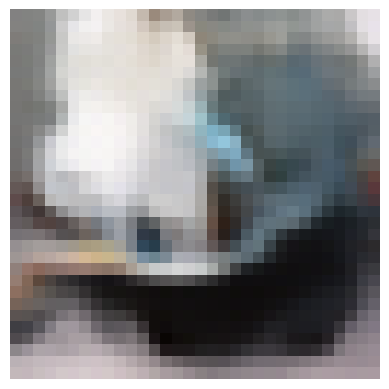

In [ ]:
@torch.no_grad()
def generate_image(model, steps=20, config=config, image_size=32, device="cuda"):
  model.eval()
  x = torch.randn(1, 3, image_size, image_size, device=device)
  dt = 1.0 / steps
  with torch.no_grad():
    for step in range(steps):
      t_val = step * dt
      t = torch.tensor([t_val], device=device)
      v_pred = model(x, t * 1000)
      x = x + v_pred * dt
    x = (x.clamp(-1, 1) + 1) / 2
  return x

img = generate_image(dit, config=config)
plt.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

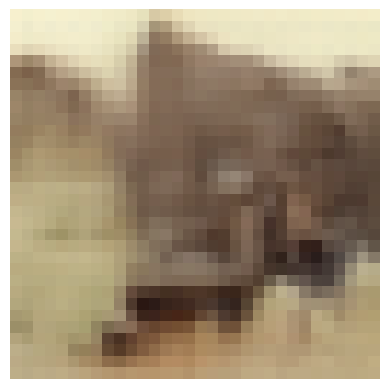

In [ ]:
img = generate_image(dit, config=config)
plt.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

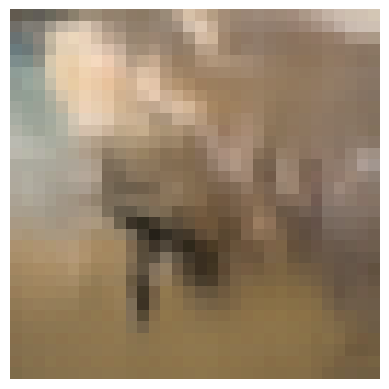

In [ ]:
img = generate_image(dit, config=config)
plt.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

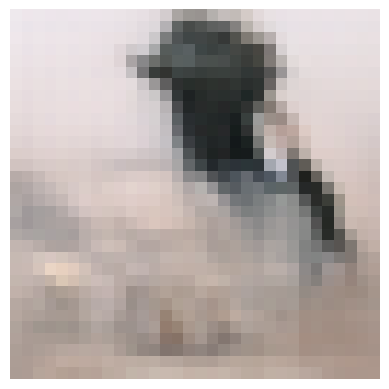

In [ ]:
img = generate_image(dit, config=config)
plt.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

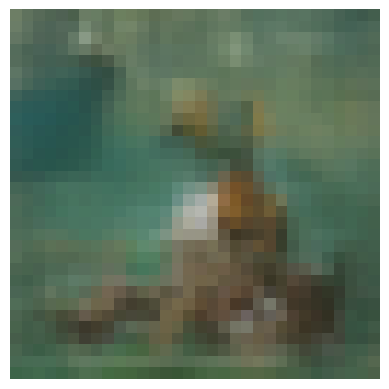

In [ ]:
img = generate_image(dit, config=config)
plt.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()